In [ ]:
# install missing modules with !pip install ....
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft, fftfreq, fftshift
from scipy.integrate import trapezoid
from scipy.linalg import expm
from matplotlib.animation import FuncAnimation, FFMpegWriter
from tqdm import tqdm 
from IPython.display import display, clear_output, Image

In [ ]:
# Constants
hbar = 1.0  # Planck's constant
u_em = 1822.89 # one atomic mass unit in electron masses
a0 = 0.5292 # Bohr radius in Angstrom (1 Angstrom = 1.89 a.u.)
au_ev = 27.21 # conversion to eV

**Goal:** Numerically solve the TDSE
$$
i\hbar \frac{\partial}{\partial t}
\begin{pmatrix}
\textcolor{black}{\psi_2(t)} \\[6pt]
\textcolor{black}{\psi_1(t)}
\end{pmatrix}
=
\begin{pmatrix}
\hat{T} + \textcolor{black}{\hat{V}_2} & \textcolor{black}{\hat{V}_{12}} - \textcolor{black}{\hat{\mu}} \varepsilon(t) \\[6pt]
-\textcolor{black}{\hat{V}_{12}} - \textcolor{black}{\hat{\mu}} \varepsilon(t) & \hat{T} + \textcolor{black}{\hat{V}_1}
\end{pmatrix}
\begin{pmatrix}
\textcolor{black}{\psi_2(t)} \\[6pt]
\textcolor{black}{\psi_1(t)}
\end{pmatrix}
$$

There exist a vast variety of methods to do this, each with their own advantages and limitations.  
Our method is called exact grid-based quantum dynamics.   
**Advantage:** Exact solution of the TDSE.  
**Limitation:** Only possible in up to 3 nuclear degrees of freedom.

<span style="color:orange; font-weight:bold;">### SOME REFERENCES (SELECTIVE) ###</span>  
[1] Book: "Introduction to Quantum Mechanics: A Time-dependent Perspective" by David Tannor.  
[2] Book chapter: S. Reiter, D. Keefer, and R. de Vivie-Riedle Exact Quantum Dynamics (Wave Packets) in Reduced Dimensionality, in Quantum Chemistry and Dynamics of Excited States (Wiley, 2020), pp. 355–381.  



<span style="color:orange; font-weight:bold;">(1) DEFINE REAL-SPACE AND MOMENTUM GRID</span>  
**Molecular process:** Na---F Photodissociation.  
**Model**: 2 coupled electronic states.

In [ ]:
# Read in grid and potential files
# Spatial grid
x = np.loadtxt('naf_data/x.csv',delimiter=',') # the complete X axis
dx = x[2]-x[1] # distance between two grid points
nx = x.size # Amount of grid points

# Frequency axis
k = fftfreq(nx, d=dx) * 2 * np.pi


To discretize the wave function without loss of information one has to follow the Nyquist-Shannon sampling theorem:  
"A continuous signal can be perfectly reconstructed from its discrete samples if the sampling rate is at least twice the highest frequency present in the signal."   

This directly links the spacing dx with the largest representable momentum via $$dx \leq \frac{\pi \hbar}{p_{max}} = \frac{\pi}{k_{max}}$$. Or, in other words, the momentum grid cutoff is $$ p_{max} = \frac{\hbar \pi}{dx}$$


<span style="color:orange; font-weight:bold;">(2) LOAD POTENTIAL ENERGY CURVES AND COUPLING ELEMENTS</span>  

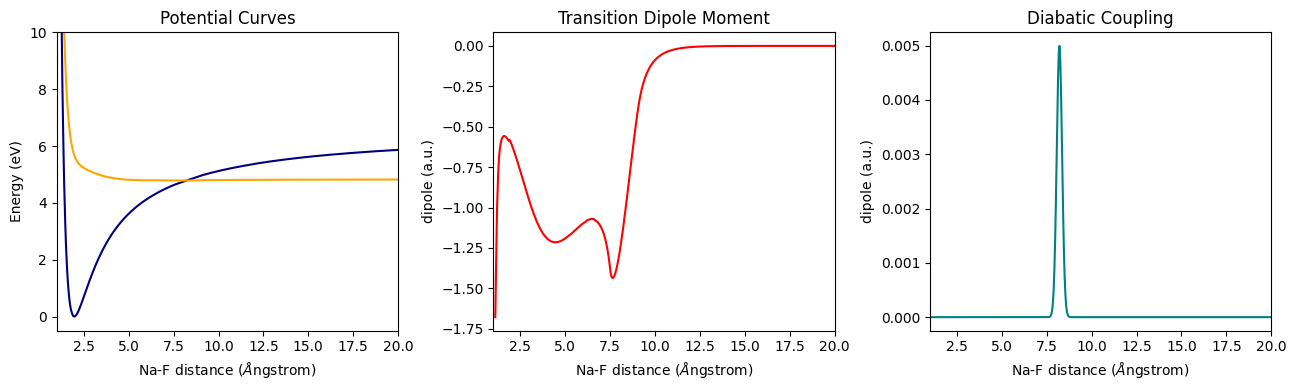

In [ ]:
# Diabatic state 1
V1 = np.loadtxt('naf_data/d0.csv',delimiter=',')
# Diabatic state 2
V2 = np.loadtxt('naf_data/d1.csv',delimiter=',')
# Transition dipole moment
mu12 = np.loadtxt('naf_data/dipole_01.csv',delimiter=',')
# Diabatic coupling
V12 = np.loadtxt('naf_data/dc.csv',delimiter=',')

# Plot
fig, (axs) = plt.subplots(1, 3, figsize=(13, 4))  # 1 row, 2 columns

# Potential energy curves
axs[0].plot(x*a0,V1*au_ev, 'navy')
axs[0].plot(x*a0,V2*au_ev, 'orange')
axs[0].set_ylim(-0.5,10)
axs[0].set_title('Potential Curves')
axs[0].set_xlabel(r'Na-F distance ($\AA$ngstrom)')
axs[0].set_ylabel('Energy (eV)')

# Transition dipole moment
axs[1].plot(x*a0, mu12, 'r')
axs[1].set_title('Transition Dipole Moment')
axs[1].set_xlabel(r'Na-F distance ($\AA$ngstrom)')
axs[1].set_ylabel('dipole (a.u.)')

# Diabatic coupling
axs[2].plot(x*a0, V12, 'teal')
axs[2].set_title('Diabatic Coupling')
axs[2].set_xlabel(r'Na-F distance ($\AA$ngstrom)')
axs[2].set_ylabel('dipole (a.u.)')

#adjust xlim
for ax in axs:
    ax.set_xlim(1,20)

plt.tight_layout()  # Adjusts spacing between plots
plt.show()

$$
i\hbar \frac{\partial}{\partial t}
\begin{pmatrix}
\textcolor{lightgray}{\psi_2(t)} \\[6pt]
\textcolor{lightgray}{\psi_1(t)}
\end{pmatrix}
=
\begin{pmatrix}
\textcolor{lightgray}{\hat{T}} + \textcolor{orange}{\hat{V}_2} & \textcolor{teal}{\hat{V}_{12}} - \textcolor{red}{\hat{\mu}} \textcolor{lightgray}{\varepsilon(t)} \\[6pt]
-\textcolor{teal}{\hat{V}_{12}} - \textcolor{red}{\hat{\mu}} \textcolor{lightgray}{\varepsilon(t)} & \textcolor{lightgray}{\hat{T}} + \textcolor{navy}{\hat{V}_1}
\end{pmatrix}
\begin{pmatrix}
\textcolor{lightgray}{\psi_2(t)} \\[6pt]
\textcolor{lightgray}{\psi_1(t)}
\end{pmatrix}
$$


<span style="color:orange; font-weight:bold;">(3) DEFINE WAVE FUNCTION AT TIME ZERO</span>  

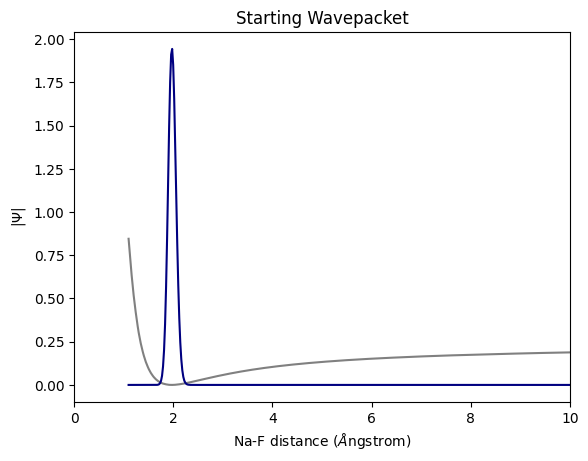

In [ ]:
# Starting wave packet
psi0=np.zeros((nx,2),dtype=complex)
psi0[:,0] = np.loadtxt('naf_data/wf0.csv',delimiter=',') # read in wave packet

#Normalize the wave packet
norm = trapezoid(psi0[:, 0] * np.conjugate(psi0[:, 0]), x=x)
psi0=psi0/np.sqrt(norm)

#Plot it
plt.clf()
plt.plot(x*a0,V1,'grey')
plt.plot(x*a0,abs(psi0[:,0]),'navy')
plt.xlim(0, 10)
plt.title("Starting Wavepacket")
plt.xlabel(r'Na-F distance ($\AA$ngstrom)')
plt.ylabel(r'$\vert \Psi \vert$')
plt.show()

$$
i\hbar \frac{\partial}{\partial t}
\begin{pmatrix}
\textcolor{black}{\psi_2(t)} \\[6pt]
\textcolor{black}{\psi_1(t)}
\end{pmatrix}
=
\begin{pmatrix}
\textcolor{lightgray}{\hat{T}} + \textcolor{orange}{\hat{V}_2} & \textcolor{teal}{\hat{V}_{12}} - \textcolor{red}{\hat{\mu}} \textcolor{lightgray}{\varepsilon(t)} \\[6pt]
-\textcolor{teal}{\hat{V}_{12}} - \textcolor{red}{\hat{\mu}} \textcolor{lightgray}{\varepsilon(t)} & \textcolor{lightgray}{\hat{T}} + \textcolor{navy}{\hat{V}_1}
\end{pmatrix}
\begin{pmatrix}
\textcolor{black}{\psi_2(t)} \\[6pt]
\textcolor{black}{\psi_1(t)}
\end{pmatrix}
$$


<span style="color:orange; font-weight:bold;">(4) DEFINE TIME AXIS AND LASER FIELD</span> 

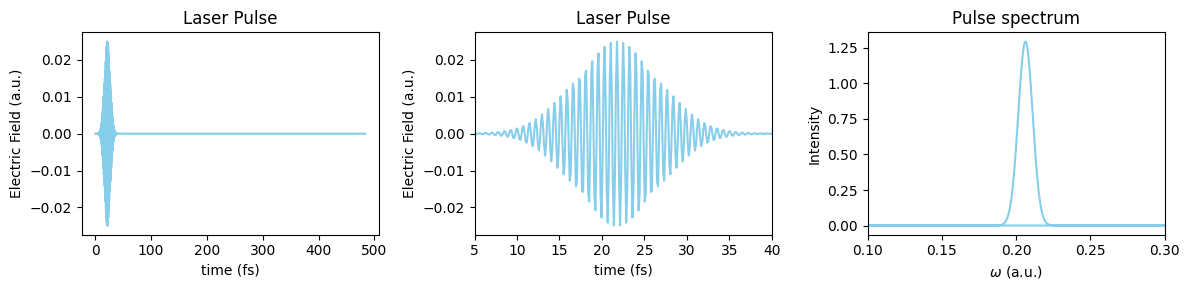

In [ ]:

# Time axis
dt = 5   # Time step
nt = 4000  # Number of time steps
t0 = 900  # time of maximum pulse intensity
t = np.arange(0,dt*nt,dt) # Time axis

# Laser parameters
E0 = 0.025 # Maximum field intensity
sigma_f = 5*41.34 # FWHM
omega = 0.2063 # Field frequency

field = E0*np.exp(-0.5*((t-t0)/sigma_f)**2)*np.cos(omega*(t-t0))

fig, (axs) = plt.subplots(1, 3, figsize=(12, 3))  # 1 row, 2 columns

# Laser field
axs[0].plot(t/41.34,field, 'skyblue')
axs[0].set_title('Laser Pulse')
axs[0].set_xlabel('time (fs)')
axs[0].set_ylabel('Electric Field (a.u.)')

# Laser field zoom
axs[1].plot(t/41.34,field, 'skyblue')
axs[1].set_xlim(5,40)
axs[1].set_title('Laser Pulse')
axs[1].set_xlabel('time (fs)')
axs[1].set_ylabel('Electric Field (a.u.)')

# Transition dipole moment
axs[2].plot(fftfreq(nt, d=dt) * 2 * np.pi,abs(fft(field)), 'skyblue')
axs[2].set_title('Pulse spectrum')
axs[2].set_xlabel(r'$\omega$ (a.u.)')
axs[2].set_ylabel('Intensity')
axs[2].set_xlim(0.1, 0.3)

plt.tight_layout()  # Adjusts spacing between plots
plt.show()

$$
i\hbar \frac{\partial}{\partial t}
\begin{pmatrix}
\textcolor{black}{\psi_2(t)} \\[6pt]
\textcolor{black}{\psi_1(t)}
\end{pmatrix}
=
\begin{pmatrix}
\textcolor{lightgray}{\hat{T}} + \textcolor{orange}{\hat{V}_2} & \textcolor{teal}{\hat{V}_{12}} - \textcolor{red}{\hat{\mu}} \textcolor{skyblue}{\varepsilon(t)} \\[6pt]
-\textcolor{teal}{\hat{V}_{12}} - \textcolor{red}{\hat{\mu}} \textcolor{skyblue}{\varepsilon(t)} & \textcolor{lightgray}{\hat{T}} + \textcolor{navy}{\hat{V}_1}
\end{pmatrix}
\begin{pmatrix}
\textcolor{black}{\psi_2(t)} \\[6pt]
\textcolor{black}{\psi_1(t)}
\end{pmatrix}
$$




<span style="color:orange; font-weight:bold;">(5) SET POTENTIAL AND KINETIC ENERGY OPERATOR AND WAVE FUNCTION MATRICES</span> 


The kinetic energy operator is evaluated using the fast Fourier transform.
This method takes advantage of the fact that the momentum operator and its square are non-local in the coordinate representation but local in the momentum representation, where their action can be evaluated by simple multiplication. For the complete operation $ \hat{H}\Psi(t)$ the wave function is Fourier-transformed to the momentum space before the second derivative operator of the kinetic part is applied:

$$
\frac{\partial^2}{\partial x^2} \Psi(x)
= \frac{1}{2\pi} \int^{+ \infty}_{- \infty}  \left[ \Psi (k) e^{ikx} \right] dk
= \frac{1}{2\pi} \int^{+ \infty}_{- \infty}  -k^2 \Psi (k) e^{ikx} dk 
$$

As the potential energy operator is local in the coordinate representation, the wave function has to be transformed back to the real space. In the context of quantum dynamics, the sequence
$$
\Psi (x)  \xrightarrow{\text{IFT}} \Psi (k) \rightarrow -k^2\Psi (k) \xrightarrow{\text{FT}} \frac{\partial^2}{\partial x^2} \Psi (x)
$$
is applied in each time step dt.

In [ ]:
psi = np.copy(psi0)
popV1 = np.zeros(nt)
popV2 = np.zeros(nt)

V = np.zeros((nx, 2, 2), dtype=complex)
V[:, 0, 0] = V1
V[:, 1, 1] = V2

mass = ((19*23)/(19+23))*u_em
T = k ** 2 / (2 * mass)

$$
i\hbar \frac{\partial}{\partial t}
\begin{pmatrix}
\textcolor{black}{\psi_2(t)} \\[6pt]
\textcolor{black}{\psi_1(t)}
\end{pmatrix}
=
\begin{pmatrix}
\textcolor{black}{\hat{T}} + \textcolor{orange}{\hat{V}_2} & \textcolor{teal}{\hat{V}_{12}} - \textcolor{red}{\hat{\mu}} \textcolor{skyblue}{\varepsilon(t)} \\[6pt]
-\textcolor{teal}{\hat{V}_{12}} - \textcolor{red}{\hat{\mu}} \textcolor{skyblue}{\varepsilon(t)} & \textcolor{black}{\hat{T}} + \textcolor{navy}{\hat{V}_1}
\end{pmatrix}
\begin{pmatrix}
\textcolor{black}{\psi_2(t)} \\[6pt]
\textcolor{black}{\psi_1(t)}
\end{pmatrix}
$$

<span style="color:orange; font-weight:bold;">(6) TIME PROPAGATION WITH SPLIT OPERATOR</span> 

Discretization in time:
Propagation over whole time interval is split in *Nt* time intervals with step size *dt*: *t* = *Nt* * *dt* 
$$
U(t,0) = e^{-i\hat{H}dt/\hbar} * e^{-i\hat{H}dt/\hbar} * .... * e^{-i\hat{H}dt/\hbar}
$$
Simple splitting of *H* into *T* and *V* introduces an error:
$$
e^{-i\hat{H}dt/\hbar} = e^{-i(\hat{T} + \hat{V}) dt/\hbar} \approx e^{-i\hat{V}dt/\hbar} * e^{-i\hat{T}dt/\hbar} + \mathcal{O}(dt^2)
$$
Reduction of error by symmetrized product of two half-steps:
$$
e^{-i(\hat{T} + \hat{V}) dt/\hbar} \approx \{  e^{-i\hat{T}dt/2\hbar} * e^{-i\hat{V}dt/2\hbar} \} \{  e^{-i\hat{V}dt/2\hbar} * e^{-i\hat{T}dt/2\hbar} \} \mathcal{O}(dt^3)
$$
\textcolor{orange}
$$
\textcolor{orange}{= e^{-i\hat{T}dt/2\hbar} * e^{-i\hat{V}dt/\hbar} * e^{-i\hat{T}dt/2\hbar}} \mathcal{O}(dt^3)
$$

In [ ]:
# Define variables for storage:
psit0 = []
psit1 = []
coherence = np.zeros(nt, dtype=complex)

# exp(T) can be defined outside of the loop
expT = np.exp(-1j * T * dt / 2)

# perform propagation
for n in tqdm(range(nt), desc="Time Evolution Progress"):
    # Define coupling term
    coupling = V12 - mu12*field[n]
    V[:, 0, 1] = coupling
    V[:, 1, 0] = coupling
    
    # First half of kinetic step:
    for state in range(len(psi[0,:])):
        psi[:,state] = ifft(expT * fft(psi[:,state]))
        # Fourier transform -> Multiply with T -> Inverse Fourier transform
    
    # Full potential step:
    psi = np.einsum("ijk,ik->ij", expm(-1j * V * dt), psi)
    # This is an efficient version avoiding the loop over each grid point
    # expm(...):                    Matrix exponential (potential operator in time evolution)
    # np.einsum("ijk,ik->ij", ...): Batch 2x2 matrix multiplication (for each grid point)

    # Second half of kinetic step:
    for state in range(len(psi[0,:])):
        psi[:,state] = ifft(expT * fft(psi[:,state]))
        # Fourier transform -> Multiply with T -> Inverse Fourier transform

    # Store ψ for animation
    psit0.append(psi[:, 0])
    psit1.append(psi[:, 1])
    # Compute population and coherences
    coherence[n] = np.vdot(psi[:, 1], psi[:, 0]) * dx
    popV1[n] = np.vdot(psi[:, 0], psi[:, 0]) * dx
    popV2[n] = np.vdot(psi[:, 1], psi[:, 1]) * dx
    

/var/folders/jz/mfx4qfk14tl782flc96m104m0000gn/T/ipykernel_90490/4262743544.py:37: ComplexWarning: Casting complex values to real discards the imaginary part | 0/4000 [00:00<?, ?it/s]
  popV1[n] = np.vdot(psi[:, 0], psi[:, 0]) * dx
/var/folders/jz/mfx4qfk14tl782flc96m104m0000gn/T/ipykernel_90490/4262743544.py:38: ComplexWarning: Casting complex values to real discards the imaginary part
  popV2[n] = np.vdot(psi[:, 1], psi[:, 1]) * dx
Time Evolution Progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [01:42<00:00, 38.93it/s]


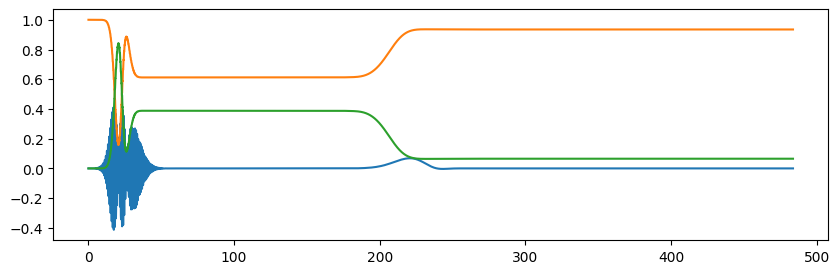

In [ ]:
plt.figure(figsize=(10, 3))
plt.plot(t/41.34,np.real(coherence))
plt.plot(t/41.34,popV1)
plt.plot(t/41.34,popV2)
plt.show()

In [ ]:
# --- Plot Setup for Animation ---
fig, (axs) = plt.subplots(2, 1, figsize=(10,6))  # 2 row, 1 columns
line_psi0, = axs[0].plot(x, np.abs(psit0[3999]), color='navy', label=r'$|\Psi_0|^2$')
line_psi1, = axs[0].plot(x, np.abs(psit1[3999])+0.5, color='orange', label=r'$|\Psi_1|^2$')
line_time = axs[0].text(20, 1, f'time: {0:.1f} fs', fontsize=12)
axs[0].set_title('Wavepacket evolution')
axs[0].set_xlabel(r'Na-F distance ($\AA$ngstrom)')
axs[0].set_ylabel(r'$\vert \Psi \vert $(arb. u.)')
axs[1].set_title('Potential energy curves')
axs[1].plot(x,V1*au_ev, color='navy')
axs[1].plot(x,V2*au_ev, color='orange',)
axs[1].set_ylim(-0.5,8)
axs[1].set_title('Potential Curves')
axs[1].set_xlabel(r'Na-F distance ($\AA$ngstrom)')
axs[1].set_ylabel('Energy (eV)')
axs[1].set_title('Potential energy curves')
plt.tight_layout()

# --- Animation Update Function ---
def update(frame):
    line_psi0.set_ydata(abs(psit0[frame]))
    line_psi1.set_ydata(abs(psit1[frame]))
    line_time.set_text(f'time: {frame * dt / 41.34:.1f} fs') 
    return line_psi0, line_psi1, line_time

# --- Create Animation ---
fps = 120
ani = FuncAnimation(fig, update, frames=nt, blit=True, interval=1000/fps)

# --- Export Animation as MP4 ---
output_filename = "wavefunction_evolution.mp4"
writer = FFMpegWriter(fps=fps, metadata=dict(artist='Wavefunction Simulation'), bitrate=1800)

ani.save(output_filename, writer=writer)

plt.close(fig)  # Close figure after saving

print(f"✅ Animation saved successfully as {output_filename} 🎬")

#from IPython.display import FileLink
#FileLink(r'wavefunction_evolution.mp4')



✅ Animation saved successfully as wavefunction_evolution.mp4 🎬


<span style="color:orange; font-weight:bold;">#### TRUECARS ####</span> 

Signal Formula:
$$
S(\omega ,t) = 2 \mathcal{I} \int_{- \infty}^{\infty} dt e^{i \omega (t-T)} \varepsilon_0^{\ast} (\omega) \varepsilon_1 (t-T)  \\
	\times \langle \psi (t) \vert \hat \alpha \vert \psi (t) \rangle
$$

$ \varepsilon_0^{\ast} (\omega) $: defined in frequency.  
$ \varepsilon_1 (t-T) $: defined in time => gates the transition polarizability.  
$ \langle \psi (t) \vert \hat \alpha \vert \psi (t) \rangle $ polarizability expectation value.  


**Transition polarizability:**
$$ \hat{\alpha} = \begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
$$
is assumed to be **constant** over the nuclear space.  
Electronic populations do not contribute since they carry no dynamical phase and vanish when taking the imaginary part.  
The time dependent material property then amounts to:
$$ \langle \psi (t) \vert \hat \alpha \vert \psi (t) \rangle = \langle
\begin{pmatrix} \Psi_1(t)  \\ \Psi_2 (t) \end{pmatrix} \vert
\begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} \vert
\begin{pmatrix} \Psi_1(t)  \\ \Psi_2 (t) \end{pmatrix} \vert \rangle
= \textcolor{orange}{2 \mathcal{R} \langle \Psi_1(t) \vert \Psi_2(t) \rangle}
$$

Inspecting the signal formula, we need to define the $ \varepsilon_0 (\omega) $ and $ \varepsilon_1 (t-T) $ probe fields:

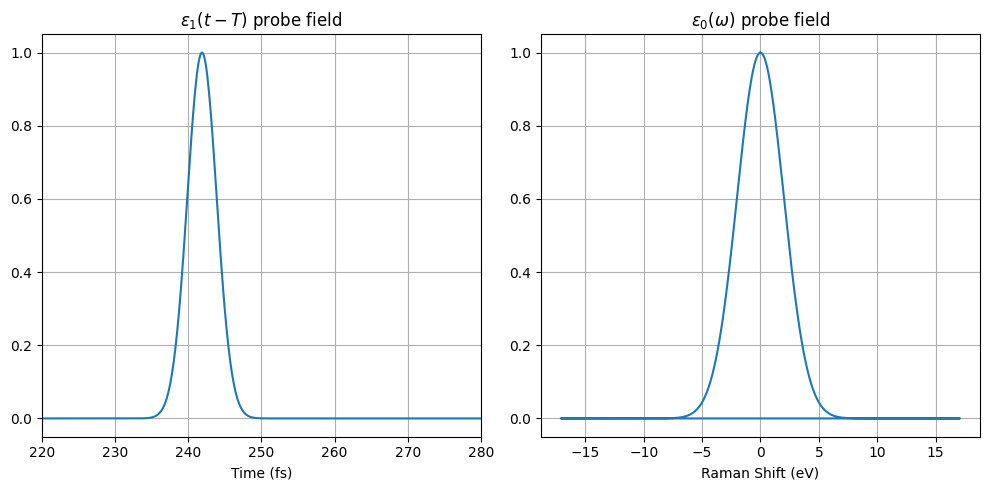

In [ ]:
st = 2* 41.34  # sigma in fs converted to a.u.
sw = 2 / 27.21  # sigma in eV converted to a.u.

w = np.fft.fftfreq(nt, dt) * 2 * np.pi  # Frequency axis

e1field = np.exp(-((t - (2000) * dt) ** 2) / (2 * st**2))
e0field = np.exp(-w ** 2 / (2* sw ** 2))
#e0field = abs(np.fft.fft(e1field))

fig, axs = plt.subplots(1, 2, figsize=(10, 5)) 

# Subplot 1: E1(t) probe field
k = 2000 # Choose a current time for E1 field
axs[0].plot(t / 41.34, e1field)
axs[0].set_title(r'$\varepsilon_1 (t-T)$ probe field')
axs[0].set_xlabel('Time (fs)')
axs[0].grid(True)
axs[0].set_xlim(220, 280)

# Subplot 2: E0(w) probe field
axs[1].plot(w * 27.21, e0field)
axs[1].set_title(r'$\varepsilon_0 (\omega)$ probe field')
axs[1].set_xlabel('Raman Shift (eV)')
axs[1].grid(True)

# --- Layout and Show ---
plt.tight_layout()
plt.show()

<span style="color:orange; font-weight:bold;">COMPUTATION OF TRUECARS</span>
$$
S(\omega ,T) = 2 \mathcal{I} \int_{- \infty}^{\infty} dt e^{i \omega (t-T)} \varepsilon_0^{\ast} (\omega) \varepsilon_1 (t-T)  \\
	\times \langle \psi (t) \vert \hat \alpha \vert \psi (t) \rangle
$$
is achieved in the following way:

In [ ]:
alpha = 2 * np.real(coherence) # alpha = 2*real part of the coherence; see above
sig = np.zeros((nt, nt)) # initialize signal matrix

for k in range(nt): # Loop over time
    time_shift = t - (k * dt)
    temporal_part = np.exp(-(time_shift ** 2) / (2 * st ** 2)) * alpha # alpha .* E1 field
    sig[:, k] = np.imag(np.fft.fftshift(np.exp(-1j * w * k * dt) * e0field * ifft(temporal_part))) 

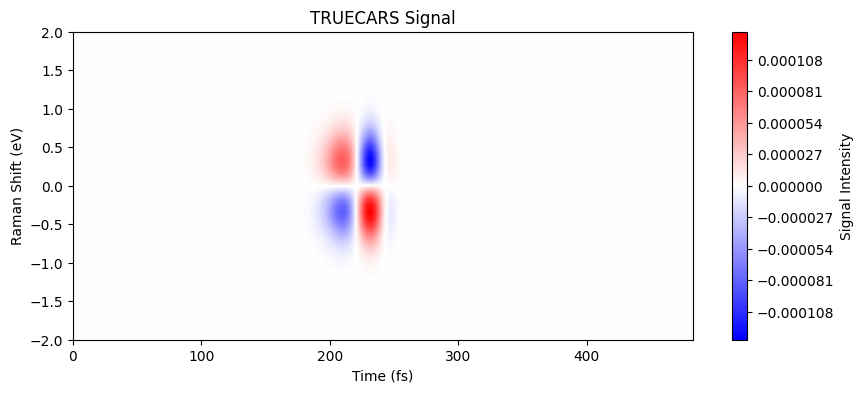

In [ ]:
pstep = 10  # Resolution adjustment for plotting

ax1, ax2 = np.meshgrid(t / 41.34, fftshift(w) * 27.21)

# Plotting
plt.figure(figsize=(10, 4))
plt.contourf(ax1[::pstep, ::pstep], ax2[::pstep, ::pstep], sig[::pstep, ::pstep], 256, cmap='bwr')
plt.colorbar(label='Signal Intensity')
plt.ylim([-2, 2])
plt.xlabel('Time (fs)')
plt.ylabel('Raman Shift (eV)')
plt.title('TRUECARS Signal')
plt.show()

<span style="color:orange; font-weight:bold;">### RELEVANT TRUECARS LITERATURE ###</span> 

Original TRUECARS formulation:  
[1] M. Kowalewski, K. Bennett, K. E. Dorfman, and S. Mukamel, *Phys. Rev. Lett.* **115**, 193003 (2015). DOI: 10.1103/PhysRevLett.115.193003  

TRUECARS for uracil photorelaxation featuring all ab-initio quantities:  
[2] D. Keefer, T. Schnappinger, R. de Vivie-Riedle, and S. Mukamel, *PNAS* **117**, 24069 (2020). DOI: 10.1073/pnas.2015988117.  

Stochastic TRUECARS + broadband vs narrowband, temporal vs spectral resolution:  
[3] S. M. Cavaletto, D. Keefer, and S. Mukamel, *Phys Rev X* **11**, 011029 (2021). DOI: 10.1103/PhysRevX.11.011029.